In [78]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

In [79]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [81]:
download(
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins_raw.csv"
)

In [82]:
columns = {
    "Body Mass (g)": "mass",
    "Flipper Length (mm)": "flipper_length",
    "Culmen Length (mm)": "culmen_length",
    "Culmen Depth (mm)": "culmen_depth",
}

In [83]:
penguins = (
    pd.read_csv("penguins_raw.csv")
    .dropna(subset=["Body Mass (g)"])
    .rename(columns=columns)
)
penguins.shape

(342, 17)

In [84]:
adelie = penguins.query('Species.str.startswith("Adelie")').copy()
len(adelie)

151

In [85]:
flipper_length = adelie["flipper_length"]
body_mass = adelie["mass"]

In [86]:
from scipy.stats import linregress

result_linregress = linregress(flipper_length, body_mass)
result_linregress.intercept, result_linregress.slope

(np.float64(-2535.8368022002514), np.float64(32.83168975115009))

In [87]:
formula = "mass ~ flipper_length"

In [88]:
import statsmodels.formula.api as smf

model = smf.ols(formula, data=adelie)
type(model)

statsmodels.regression.linear_model.OLS

In [89]:
result_ols = model.fit()

In [90]:
# Technically it's a RegressionResultsWrapper

type(result_ols)

statsmodels.regression.linear_model.RegressionResultsWrapper

In [91]:
from thinkstats import display_summary

display_summary(result_ols)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-2535.8368,964.798,-2.628,0.009,-4442.291,-629.382
flipper_length,32.8317,5.076,6.468,0.000,22.801,42.862


R-squared:,0.2192


In [92]:
result_linregress.intercept, result_linregress.slope

(np.float64(-2535.8368022002514), np.float64(32.83168975115009))

In [93]:
result_linregress.intercept_stderr, result_linregress.stderr,

(np.float64(964.7984274994059), np.float64(5.076138407990821))

In [94]:
result_ols.pvalues["flipper_length"]

np.float64(1.3432645947789321e-09)

In [95]:
result_linregress.pvalue

np.float64(1.3432645947790051e-09)

In [96]:
result_ols.rsquared, result_linregress.rvalue**2

(np.float64(0.21921282646854878), np.float64(0.21921282646854875))

In [97]:
formula = "mass ~ culmen_length"
result = smf.ols(formula, data=adelie).fit()
display_summary(result)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,34.8830,458.439,0.076,0.939,-870.998,940.764
culmen_length,94.4998,11.790,8.015,0.000,71.202,117.798


R-squared:,0.3013


In [98]:
formula = "mass ~ flipper_length + culmen_length"

In [99]:
result = smf.ols(formula, data=adelie).fit()
display_summary(result)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-3573.0817,866.739,-4.122,0.000,-5285.864,-1860.299
flipper_length,22.7024,4.742,4.787,0.000,13.331,32.074
culmen_length,76.3402,11.644,6.556,0.000,53.331,99.350


R-squared:,0.3949


In [100]:
from thinkstats import corrcoef

corrcoef(adelie, "flipper_length", "culmen_length")

np.float64(0.32578471516515944)

In [101]:
formula = "mass ~ flipper_length + culmen_length + culmen_depth"
result = smf.ols(formula, data=adelie).fit()
display_summary(result)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-4341.3019,795.117,-5.460,0.000,-5912.639,-2769.964
flipper_length,17.4215,4.385,3.973,0.000,8.756,26.087
culmen_length,55.3676,11.133,4.973,0.000,33.366,77.369
culmen_depth,140.8946,24.216,5.818,0.000,93.037,188.752


R-squared:,0.5082


In [102]:
[
    corrcoef(adelie, "culmen_depth", "flipper_length"),
    corrcoef(adelie, "culmen_depth", "culmen_length"),
]

[np.float64(0.30762017939668534), np.float64(0.39149169183587634)]

In [103]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

In [104]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [105]:
from nsfg import get_nsfg_groups

live, firsts, others = get_nsfg_groups()

In [106]:
valid = live.dropna(subset=["agepreg", "birthord", "totalwgt_lb"]).copy()

In [107]:
formula = "totalwgt_lb ~ agepreg"
result_age = smf.ols(formula, data=valid).fit()
display_summary(result_age)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.8304,0.068,100.470,0.000,6.697,6.964
agepreg,0.0175,0.003,6.559,0.000,0.012,0.023


R-squared:,0.004738


In [108]:
totalwgt = valid["totalwgt_lb"]
agepreg = valid["agepreg"]

In [109]:
agepreg_range = np.linspace(agepreg.min(), agepreg.max())

In [110]:
df = pd.DataFrame({"agepreg": agepreg_range})

In [111]:
fit_ys = result_age.predict(df)

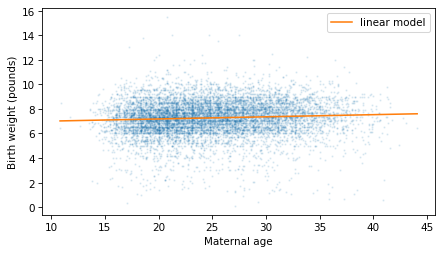

In [112]:
plt.scatter(agepreg, totalwgt, marker=".", alpha=0.1, s=5)
plt.plot(agepreg_range, fit_ys, color="C1", label="linear model")

decorate(xlabel="Maternal age", ylabel="Birth weight (pounds)")

In [113]:
valid["is_first"] = valid["birthord"] == 1

In [114]:
from thinkstats import value_counts

# check the results
value_counts(valid["is_first"])

,count
is_first,
False,4675
True,4363


In [115]:
formula = "totalwgt_lb ~ C(is_first)"

In [116]:
result_first = smf.ols(formula, data=valid).fit()
display_summary(result_first)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,7.3259,0.021,356.007,0.000,7.286,7.366
C(is_first)[T.True],-0.1248,0.030,-4.212,0.000,-0.183,-0.067


R-squared:,0.00196


In [117]:
others["totalwgt_lb"].mean()

np.float64(7.325855614973262)

In [118]:
diff_weight = firsts["totalwgt_lb"].mean() - others["totalwgt_lb"].mean()
diff_weight

np.float64(-0.12476118453549034)

In [119]:
diff_age = firsts["agepreg"].mean() - others["agepreg"].mean()
diff_age

np.float64(-3.5864347661500275)

In [120]:
slope = result_age.params["agepreg"]
slope

np.float64(0.017453851471802638)

In [121]:
slope * diff_age

np.float64(-0.0625970997216918)

In [122]:
formula = "totalwgt_lb ~ agepreg + C(is_first)"
result = smf.ols(formula, data=valid).fit()
display_summary(result)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,6.9142,0.078,89.073,0.000,6.762,7.066
C(is_first)[T.True],-0.0698,0.031,-2.236,0.025,-0.131,-0.009
agepreg,0.0154,0.003,5.499,0.000,0.010,0.021


R-squared:,0.005289


In [123]:
valid["agepreg2"] = valid["agepreg"] ** 2

In [124]:
formula = "totalwgt_lb ~ agepreg + agepreg2"

In [125]:
result_age2 = smf.ols(formula, data=valid).fit()
display_summary(result_age2)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,5.5720,0.275,20.226,0.000,5.032,6.112
agepreg,0.1186,0.022,5.485,0.000,0.076,0.161
agepreg2,-0.0019,0.000,-4.714,0.000,-0.003,-0.001


R-squared:,0.00718


In [126]:
df = pd.DataFrame({"agepreg": agepreg_range})
df["agepreg2"] = df["agepreg"] ** 2

In [127]:
fit_ys = result_age2.predict(df)

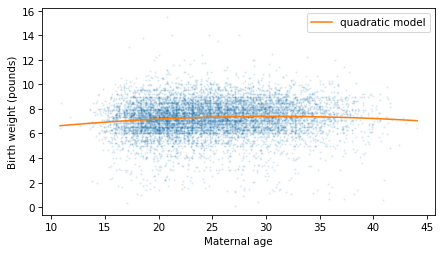

In [128]:
plt.scatter(agepreg, totalwgt, marker=".", alpha=0.1, s=5)
plt.plot(agepreg_range, fit_ys, color="C1", label="quadratic model")

decorate(xlabel="Maternal age", ylabel="Birth weight (pounds)")

In [129]:
formula = "totalwgt_lb ~ agepreg + agepreg2 + C(is_first)"
result = smf.ols(formula, data=valid).fit()
display_summary(result)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,5.6923,0.286,19.937,0.000,5.133,6.252
C(is_first)[T.True],-0.0504,0.031,-1.602,0.109,-0.112,0.011
agepreg,0.1124,0.022,5.113,0.000,0.069,0.155
agepreg2,-0.0018,0.000,-4.447,0.000,-0.003,-0.001


R-squared:,0.007462


In [130]:
adelie["y"] = (adelie["Sex"] == "MALE").astype(int)

In [131]:
adelie["y"].value_counts()

,count
y,
0,78
1,73


In [132]:
model = smf.logit("y ~ mass", data=adelie)
result = model.fit(disp=False)

In [133]:
display_summary(result)

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-25.9871,4.221,-6.156,0.000,-34.261,-17.713
mass,0.0070,0.001,6.138,0.000,0.005,0.009


Pseudo R-squared:,0.5264


In [134]:
mass = adelie["mass"]
mass_range = np.linspace(mass.min(), mass.max())
df = pd.DataFrame({"mass": mass_range})
fit_ys = result.predict(df)

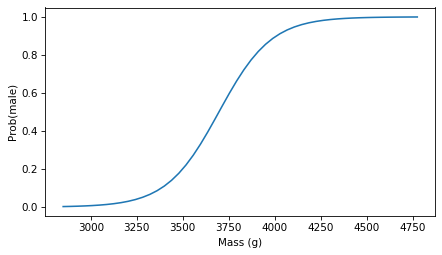

In [135]:
plt.plot(mass_range, fit_ys)

decorate(xlabel="Mass (g)", ylabel="Prob(male)")

In [136]:
formula = "y ~ mass + flipper_length + culmen_length + culmen_depth"
model = smf.logit(formula, data=adelie)
result = model.fit(disp=False)
display_summary(result)

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-60.6075,13.793,-4.394,0.000,-87.642,-33.573
mass,0.0059,0.001,4.153,0.000,0.003,0.009
flipper_length,-0.0209,0.052,-0.403,0.687,-0.123,0.081
culmen_length,0.6208,0.176,3.536,0.000,0.277,0.965
culmen_depth,1.0111,0.349,2.896,0.004,0.327,1.695


Pseudo R-squared:,0.6622


In [137]:
def plot_predictions(mass_range, culmen_length, **options):
    """Plot predicted probabilities as a function of mass."""
    df = pd.DataFrame({"mass": mass_range})
    df["flipper_length"] = adelie["flipper_length"].mean()
    df["culmen_length"] = culmen_length
    df["culmen_depth"] = adelie["culmen_depth"].mean()
    fit_ys = result.predict(df)
    plt.plot(mass_range, fit_ys, **options)

In [138]:
culmen_length = adelie["culmen_length"]
m, s = culmen_length.mean(), culmen_length.std()

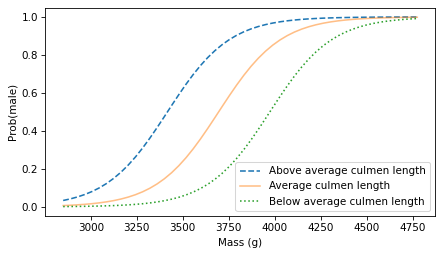

In [139]:
plot_predictions(mass_range, m + s, ls="--", label="Above average culmen length")
plot_predictions(mass_range, m, alpha=0.5, label="Average culmen length")
plot_predictions(mass_range, m - s, ls=":", label="Below average culmen length")

decorate(xlabel="Mass (g)", ylabel="Prob(male)")

In [140]:
def get_species(penguins, species):
    df = penguins.query(f'Species.str.startswith("{species}")').copy()
    df["y"] = (df["Sex"] == "MALE").astype(int)
    return df

In [141]:
gentoo = get_species(penguins, "Gentoo")
len(gentoo)

123

In [142]:
formula = "y ~ mass + flipper_length + culmen_length + culmen_depth"
model = smf.logit(formula, data=gentoo)
result = model.fit(disp=False)
display_summary(result)

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-173.9123,62.326,-2.790,0.005,-296.069,-51.756
mass,0.0105,0.004,2.948,0.003,0.004,0.017
flipper_length,0.2839,0.183,1.549,0.121,-0.075,0.643
culmen_length,0.2734,0.285,0.958,0.338,-0.286,0.833
culmen_depth,3.0843,1.291,2.389,0.017,0.554,5.614


Pseudo R-squared:,0.848


In [143]:
# Exercise 11.1

# Imports

import pandas as pd
import statsmodels.formula.api as smf

In [163]:
# If preg does not already exist, load NSFG pregnancy data first

from nsfg import read_fem_preg

preg = read_fem_preg()

# Select required columns safely

df = preg.loc[
    :,
    ['totalwgt_lb', 'babysex', 'agepreg']
].dropna()

print(df.head())

   totalwgt_lb  babysex  agepreg
0       8.8125      1.0    33.16
1       7.8750      2.0    39.25
2       9.1250      1.0    14.33
3       7.0000      2.0    17.83
4       6.1875      2.0    18.33


In [164]:
# Linear regression:
# weight ~ baby sex

model1 = smf.ols(
    'totalwgt_lb ~ C(babysex)',
    data=df
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            totalwgt_lb   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     100.8
Date:                Sun, 17 May 2026   Prob (F-statistic):           1.34e-23
Time:                        15:54:11   Log-Likelihood:                -15868.
No. Observations:                9038   AIC:                         3.174e+04
Df Residuals:                    9036   BIC:                         3.175e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.4114      0.02

In [165]:
# Linear regression controlling for mother's age

model2 = smf.ols(
    'totalwgt_lb ~ C(babysex) + agepreg',
    data=df
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            totalwgt_lb   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     72.14
Date:                Sun, 17 May 2026   Prob (F-statistic):           8.26e-32
Time:                        15:54:15   Log-Likelihood:                -15847.
No. Observations:                9038   AIC:                         3.170e+04
Df Residuals:                    9035   BIC:                         3.172e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             6.9783      0.06

In [145]:
# Exercise 11.2

valid["y"] = (valid["babysex"] == 1).astype(int)

In [166]:
# Recode sex:
# boys = 1
# girls = 0

df2 = preg[
    ['babysex', 'agepreg']
].dropna()

df2['boy'] = (df2['babysex'] == 1).astype(int)

In [167]:
# Logistic regression:
# probability of boy ~ mother's age

logit1 = smf.logit(
    'boy ~ agepreg',
    data=df2
).fit()

print(logit1.summary())

Optimization terminated successfully.
         Current function value: 0.693015
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:                    boy   No. Observations:                 9141
Model:                          Logit   Df Residuals:                     9139
Method:                           MLE   Df Model:                            1
Date:                Sun, 17 May 2026   Pseudo R-squ.:               1.882e-05
Time:                        15:54:21   Log-Likelihood:                -6334.9
converged:                       True   LL-Null:                       -6335.0
Covariance Type:            nonrobust   LLR p-value:                    0.6253
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0149      0.096     -0.156      0.876      -0.203       0.173
agepreg        0.0018      0.

In [168]:
# Quadratic model

df2['agepreg2'] = df2['agepreg']**2

logit2 = smf.logit(
    'boy ~ agepreg + agepreg2',
    data=df2
).fit()

print(logit2.summary())

Optimization terminated successfully.
         Current function value: 0.692932
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:                    boy   No. Observations:                 9141
Model:                          Logit   Df Residuals:                     9138
Method:                           MLE   Df Model:                            2
Date:                Sun, 17 May 2026   Pseudo R-squ.:               0.0001392
Time:                        15:54:24   Log-Likelihood:                -6334.1
converged:                       True   LL-Null:                       -6335.0
Covariance Type:            nonrobust   LLR p-value:                    0.4141
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4511      0.390      1.158      0.247      -0.312       1.215
agepreg       -0.0356      0.

In [148]:
# Exercise 11.3

# Imports

import numpy as np
import matplotlib.pyplot as plt

In [149]:
# Download penguin dataset

!wget -nc https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins_raw.csv

File ‘penguins_raw.csv’ already there; not retrieving.



In [150]:
# Read dataset

penguins = pd.read_csv("penguins_raw.csv")

In [151]:
# Select Adelie penguins

adelie = penguins[
    penguins["Species"].str.startswith("Adelie")
]

In [152]:
# Select variables

df = adelie[
    [
        "Body Mass (g)",
        "Flipper Length (mm)",
        "Culmen Depth (mm)",
        "Sex"
    ]
].dropna()

In [153]:
# Linear regression model

model = smf.ols(
    'Q("Body Mass (g)") ~ Q("Flipper Length (mm)") + Q("Culmen Depth (mm)") + C(Sex)',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Q("Body Mass (g)")   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     75.06
Date:                Sun, 17 May 2026   Prob (F-statistic):           3.81e-29
Time:                        15:35:17   Log-Likelihood:                -1032.0
No. Observations:                 146   AIC:                             2072.
Df Residuals:                     142   BIC:                             2084.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [154]:
# Average culmen depth

avg_depth = df['Culmen Depth (mm)'].mean()

# Range of flipper lengths

flippers = np.linspace(
    df['Flipper Length (mm)'].min(),
    df['Flipper Length (mm)'].max(),
    100
)

In [155]:
# Prediction dataframe for males

male_df = pd.DataFrame({
    'Flipper Length (mm)': flippers,
    'Culmen Depth (mm)': avg_depth,
    'Sex': 'MALE'
})

# Prediction dataframe for females

female_df = pd.DataFrame({
    'Flipper Length (mm)': flippers,
    'Culmen Depth (mm)': avg_depth,
    'Sex': 'FEMALE'
})

In [156]:
# Predictions

male_pred = model.predict(male_df)

female_pred = model.predict(female_df)

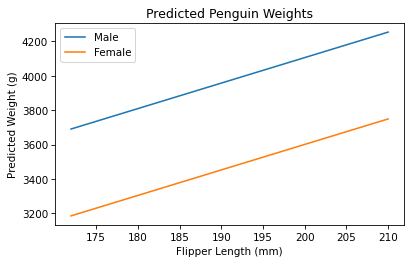

In [157]:
# Plot predictions

plt.plot(
    flippers,
    male_pred,
    label='Male'
)

plt.plot(
    flippers,
    female_pred,
    label='Female'
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Predicted Weight (g)")
plt.title("Predicted Penguin Weights")

plt.legend()

plt.show()

In [ ]:
chinstrap = get_species(penguins, "Chinstrap")
len(chinstrap)

In [158]:
# Exercise 11.4

# Select Chinstrap penguins

chinstrap = penguins[
    penguins["Species"].str.startswith("Chinstrap")
]

In [159]:
# Select variables

df = chinstrap[
    [
        "Sex",
        "Culmen Length (mm)",
        "Culmen Depth (mm)",
        "Flipper Length (mm)",
        "Body Mass (g)"
    ]
].dropna()

In [160]:
# Recode sex:
# male = 1
# female = 0

df['male'] = (df['Sex'] == 'MALE').astype(int)

In [161]:
# Logistic regression model

logit_model = smf.logit(
    'male ~ Q("Culmen Length (mm)") + Q("Culmen Depth (mm)") + Q("Flipper Length (mm)") + Q("Body Mass (g)")',
    data=df
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.217855
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                   male   No. Observations:                   68
Model:                          Logit   Df Residuals:                       63
Method:                           MLE   Df Model:                            4
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.6857
Time:                        15:35:35   Log-Likelihood:                -14.814
converged:                       True   LL-Null:                       -47.134
Covariance Type:            nonrobust   LLR p-value:                 3.064e-13
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                  -95.7490     27.368     -3.499      0.000    -149.389

In [162]:
# Pseudo R^2

print("Pseudo R^2 =", logit_model.prsquared)

Pseudo R^2 = 0.685702336981571
